## Color Thresholding

Color thresholding is technique to filter out a specific range of colors in an image by defining upper and lower bounds in a color space .We use it segment,replace or isolate specific colors in an image.


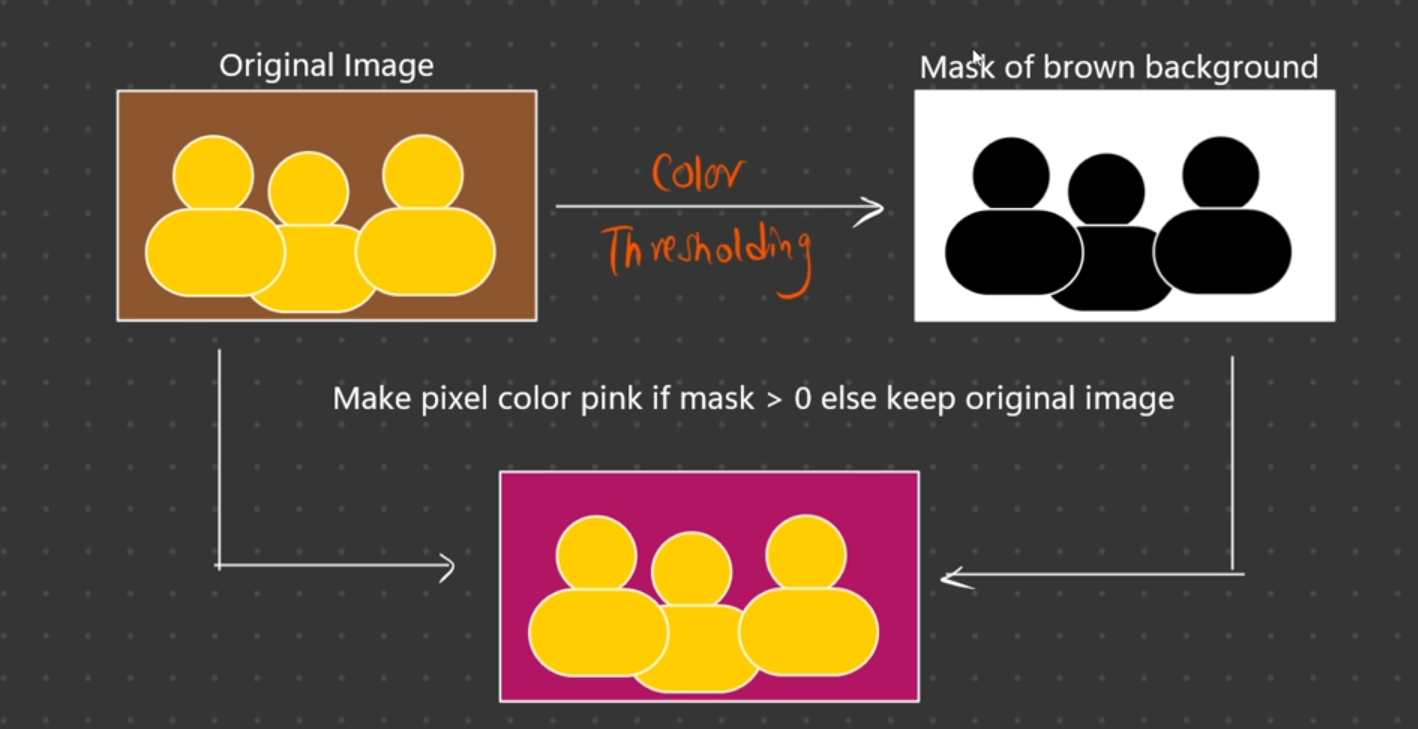

In [2]:
!pip install numpy
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.8 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.1 MB 3.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.1 MB 3.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 3.9 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 4.7 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.1 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.6 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 10.5 MB/s eta 0:

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [25]:
image = cv2.imread("asserts/img3.png")

In [41]:
image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

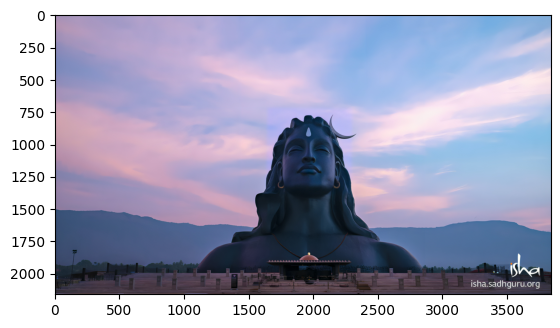

In [27]:
plt.imshow(image_rgb)
# plt.axes('off')
# plt.show()

In [28]:
hsv = cv2.cvtColor(image,cv2.COLOR_BGR2HSV)

In [29]:
lower_navy = np.array([100, 50, 20])
upper_navy = np.array([130, 255, 150])

In [30]:
# Step 4: Create mask for navy blue regions
mask = cv2.inRange(hsv, lower_navy, upper_navy)

In [31]:
# Step 5: Create a dark black color mask (near black)
black_color = np.full_like(image, (10, 10, 10))  # Almost black in BGR

In [32]:
# Step 6: Mask original image to keep only non-statue areas
image_masked = cv2.bitwise_and(image, image, mask=cv2.bitwise_not(mask))

In [33]:
# Step 7: Mask black color only where the statue is
black_masked = cv2.bitwise_and(black_color, black_color, mask=mask)

In [34]:
# Step 8: Combine both
result = cv2.add(image_masked, black_masked)

In [36]:
# Save the result
cv2.imwrite('black_statue_output.png', result)

True

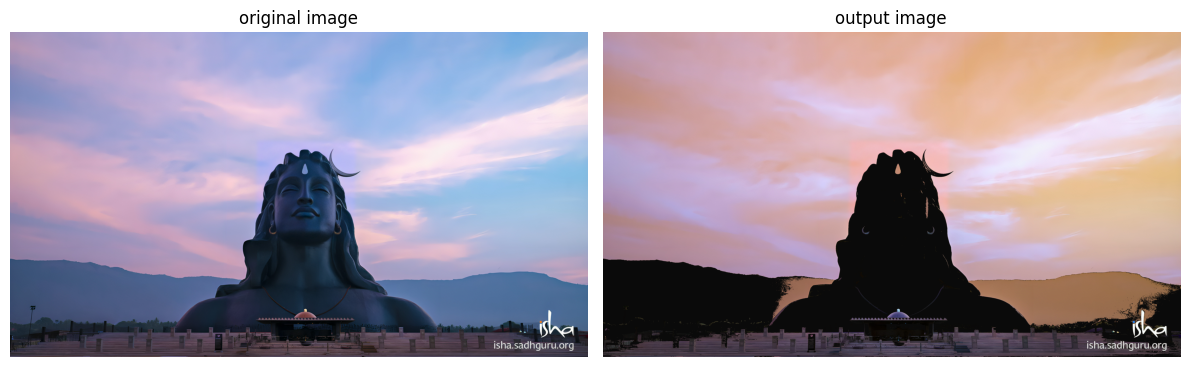

In [40]:
fig,axs = plt.subplots(1,2,figsize=(12,6))

axs[0].imshow(image_rgb)
axs[0].set_title("original image")
axs[0].axis('off')

axs[1].imshow(result)
axs[1].set_title("output image")
axs[1].axis('off')

plt.tight_layout()
plt.show()

### Function to pick the limits for masking 
```
def pick_color(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        hsv_val = hsv[y, x]
        print(f"HSV at ({x},{y}): {hsv_val}")

# Load image and convert to HSV
image = cv2.imread("asserts/img3.png")
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Show image and set mouse callback
cv2.imshow("Click to pick HSV", image)
cv2.setMouseCallback("Click to pick HSV", pick_color)
cv2.waitKey(0)
cv2.destroyAllWindows()
```
